# Phase 3a (companion) — Numerical verification of the theory

Computes and visualizes the two key objects of the theoretical analysis (`paper/phase3a_ogp.tex`):

1. **First-moment free-energy curve** $L(y;\,a,\rho) := s_\rho(y) - \tfrac{a^2}{2}(1-y)^2$, which controls the detection threshold (Theorem 3.1).
2. **Threshold-as-function-of-overlap** $a_\star(y;\rho) := \sqrt{2 s_\rho(y)}/(1-y)$, whose monotone increase on $(\rho,1)$ implies the forbidden-overlap interval $[\rho, y_a(a)]$ for every $a > a_\star(\rho)$ (Theorem 3.2).

**Outputs** (figures used in the writeup):
- `data/figs/ogp_L_curve.png` — first-moment landscape $L(y;a,\rho)$ at $\rho=0.20$ for several $a$, plus the analytical detection-threshold curve $a_\star(\rho)$.
- `data/figs/ogp_astar_y.png` — threshold-as-function-of-overlap $a_\star(y;\rho)$, monotonicity verification, and the forbidden interval $[\rho, y_a]$.
- `data/figs/ogp_phase_diagram.png` — phase diagram in the $(a, \rho)$ plane, coloured by the forbidden-interval width $y_a - \rho$.
- `data/ogp_thresholds.json` — numerical threshold values for the writeup.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

DATA_DIR = Path("data")
FIG_DIR = DATA_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-12

def h(p):
    p = np.clip(np.asarray(p, dtype=float), EPS, 1 - EPS)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)


def s_rho(y, rho):
    """Slice entropy: lim (1/n) log N_y for cardinality-rho*n subsets at planted overlap y in [rho, 1]."""
    y = np.asarray(y, dtype=float)
    arg2 = rho * (1 - y) / (1 - rho)
    arg2 = np.clip(arg2, 0.0, 1.0)
    return rho * h(y) + (1 - rho) * h(arg2)


def L_first(y, a, rho):
    """First-moment free-energy curve at calibrated threshold T = a sqrt(nk)."""
    y = np.asarray(y, dtype=float)
    return s_rho(y, rho) - 0.5 * a * a * (1 - y) ** 2


def a_star_y(y, rho):
    """Threshold-as-function-of-overlap: smallest a making L(y; a, rho) <= 0."""
    y = np.asarray(y, dtype=float)
    s = np.maximum(s_rho(y, rho), 0.0)
    denom = np.where(y < 1.0, 1.0 - y, 1e-12)
    return np.sqrt(2.0 * s) / denom


def a_detect(rho):
    """Analytical detection threshold a_*(rho) = a_*(rho; rho) = sqrt(2 h(rho)) / (1-rho)."""
    return float(np.sqrt(2 * h(np.array([rho]))[0]) / (1 - rho))


def find_y_a(a, rho, y_lo=None, y_hi=0.9999, n_grid=4000):
    """For a > a_detect(rho), find the unique y_a in (rho, 1) with L(y_a; a, rho) = 0."""
    if y_lo is None:
        y_lo = rho + 1e-4
    if a <= a_detect(rho):
        return None
    ys = np.linspace(y_lo, y_hi, n_grid)
    Lvals = L_first(ys, a, rho)
    sign_flips = np.where(np.diff(np.sign(Lvals)))[0]
    if len(sign_flips) == 0:
        return None
    i0 = int(sign_flips[0])  # the first crossing from negative to positive (the y_a we want)
    try:
        return float(optimize.brentq(lambda y: float(L_first(np.array([y]), a, rho)[0]),
                                       float(ys[i0]), float(ys[i0 + 1])))
    except ValueError:
        return float(0.5 * (ys[i0] + ys[i0 + 1]))


print("helpers ready")

helpers ready


## 1. First-moment landscape $L(y;a,\rho)$ — Theorem 3.1

Plot $L(y; a, \rho)$ for several SNR values and the detection-threshold curve $a_\star(\rho)$.

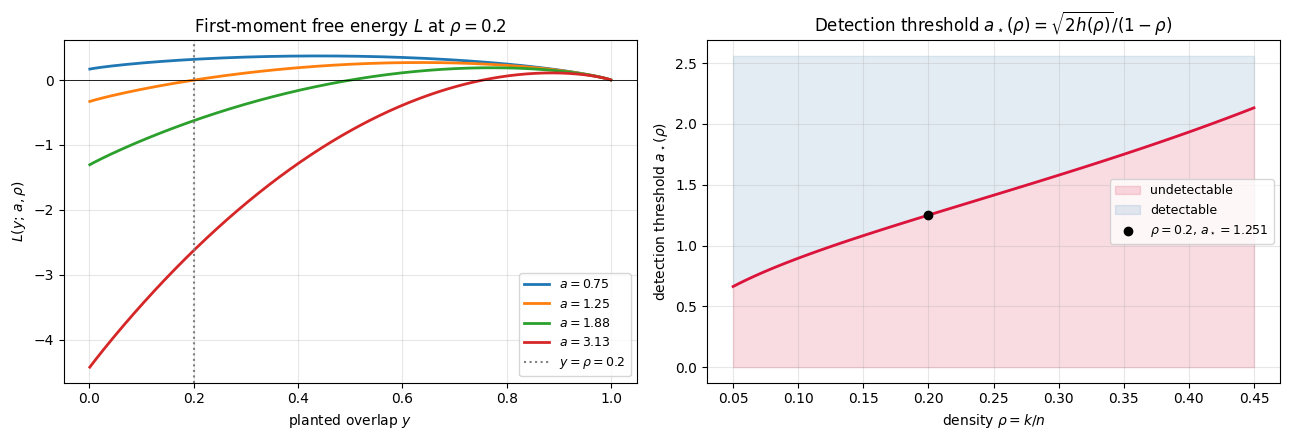

a_star(rho=0.2) = 1.2505


In [2]:
rho_grid_for_threshold = np.linspace(0.05, 0.45, 100)
a_star_curve = np.array([a_detect(r) for r in rho_grid_for_threshold])

rho_panel = 0.20
y_grid = np.linspace(0.001, 0.999, 700)
a_show = [0.6 * a_detect(rho_panel), a_detect(rho_panel), 1.5 * a_detect(rho_panel), 2.5 * a_detect(rho_panel)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for a in a_show:
    Lvals = L_first(y_grid, a=a, rho=rho_panel)
    ax.plot(y_grid, Lvals, lw=2, label=rf"$a={a:.2f}$")
ax.axhline(0, color="black", lw=0.6)
ax.axvline(rho_panel, color="gray", ls=":", label=rf"$y=\rho={rho_panel}$")
ax.set_xlabel(r"planted overlap $y$")
ax.set_ylabel(r"$L(y;\,a,\rho)$")
ax.set_title(rf"First-moment free energy $L$ at $\rho={rho_panel}$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(rho_grid_for_threshold, a_star_curve, lw=2, color="crimson")
ax.fill_between(rho_grid_for_threshold, 0, a_star_curve, alpha=0.15, color="crimson", label="undetectable")
ax.fill_between(rho_grid_for_threshold, a_star_curve, a_star_curve.max() * 1.2, alpha=0.15, color="steelblue", label="detectable")
ax.set_xlabel(r"density $\rho = k/n$")
ax.set_ylabel(r"detection threshold $a_\star(\rho)$")
ax.set_title(r"Detection threshold $a_\star(\rho)=\sqrt{2h(\rho)}/(1-\rho)$")
ax.scatter([rho_panel], [a_detect(rho_panel)], color="black", zorder=5,
           label=rf"$\rho={rho_panel}$, $a_\star={a_detect(rho_panel):.3f}$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "ogp_L_curve.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"a_star(rho={rho_panel}) = {a_detect(rho_panel):.4f}")

In [3]:
rhos_check = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
rows = []
for r in rhos_check:
    a_an = a_detect(r)
    a_num = optimize.brentq(lambda a: float(L_first(np.array([r]), a=a, rho=r)[0]), 0.01, 50.0)
    rows.append((r, a_an, a_num, abs(a_an - a_num)))
print(f"{'rho':>5}  {'a_*(analytic)':>15}  {'a_*(numeric)':>15}  {'abs error':>12}")
for r, an, nu, e in rows:
    print(f"{r:5.2f}  {an:15.6f}  {nu:15.6f}  {e:12.2e}")

  rho    a_*(analytic)     a_*(numeric)     abs error
 0.05         0.663267         0.663267      0.00e+00
 0.10         0.895921         0.895921      1.11e-16
 0.15         1.081725         1.081725      0.00e+00
 0.20         1.250503         1.250503      5.40e-14
 0.25         1.414006         1.414006      1.11e-15
 0.30         1.579026         1.579026      0.00e+00
 0.40         1.933637         1.933637      2.22e-16


## 2. The threshold-as-function-of-overlap $a_\star(y;\rho)$ — Theorem 3.2

We plot $a_\star(y;\rho) = \sqrt{2 s_\rho(y)}/(1-y)$ for several densities. Theorem 3.2 requires verifying numerically that this function is monotonically increasing on $(\rho, 1)$, in which case for every $a > a_\star(\rho)$ there is a unique $y_a\in(\rho,1)$ with $L(y_a;a,\rho)=0$, and the forbidden interval is $[\rho, y_a]$.

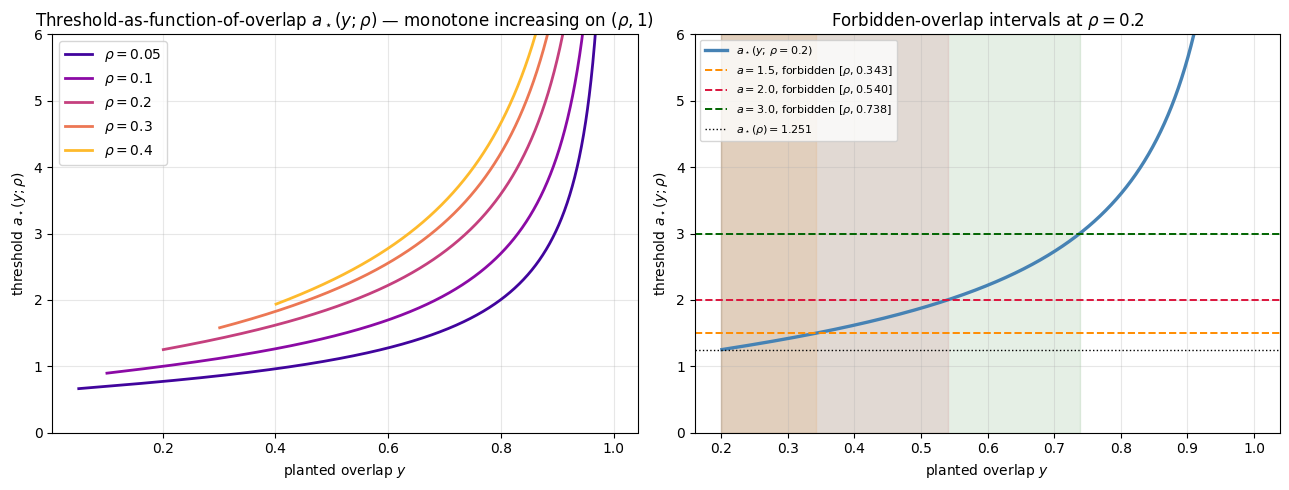

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
rho_show = [0.05, 0.10, 0.20, 0.30, 0.40]
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(rho_show)))
for c, r in zip(colors, rho_show):
    ys = np.linspace(r + 0.001, 0.995, 1500)
    ax.plot(ys, a_star_y(ys, r), lw=2, color=c, label=rf"$\rho={r}$")
ax.set_xlabel(r"planted overlap $y$")
ax.set_ylabel(r"threshold $a_\star(y;\rho)$")
ax.set_title(r"Threshold-as-function-of-overlap $a_\star(y;\rho)$ — monotone increasing on $(\rho,1)$")
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax = axes[1]
rho_panel2 = 0.20
ys = np.linspace(rho_panel2 + 0.001, 0.999, 2000)
ax.plot(ys, a_star_y(ys, rho_panel2), lw=2.4, color="steelblue", label=rf"$a_\star(y;\,\rho={rho_panel2})$")
for a_demo, color in [(1.5, "darkorange"), (2.0, "crimson"), (3.0, "darkgreen")]:
    y_a = find_y_a(a_demo, rho_panel2)
    if y_a is not None:
        ax.axhline(a_demo, color=color, ls="--", lw=1.4, label=rf"$a={a_demo}$, forbidden $[\rho, {y_a:.3f}]$")
        ax.axvspan(rho_panel2, y_a, alpha=0.10, color=color)
ax.axhline(a_detect(rho_panel2), color="black", ls=":", lw=1, label=rf"$a_\star(\rho)={a_detect(rho_panel2):.3f}$")
ax.set_xlabel(r"planted overlap $y$")
ax.set_ylabel(r"threshold $a_\star(y;\rho)$")
ax.set_title(rf"Forbidden-overlap intervals at $\rho={rho_panel2}$")
ax.set_ylim(0, 6)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "ogp_astar_y.png", dpi=130, bbox_inches="tight")
plt.show()

In [5]:
print("Forbidden-interval thresholds y_a(a) at rho=0.20:")
rows_ya = []
for a in [1.30, 1.50, 1.75, 2.00, 2.50, 3.00, 4.00, 6.00]:
    y_a = find_y_a(a, 0.20)
    rows_ya.append({"rho": 0.20, "a": a, "y_a": y_a, "forbidden_width": (y_a - 0.20) if y_a is not None else None})
    print(f"  a={a:.2f}  y_a={y_a if y_a is None else round(y_a, 4)}  forbidden_width={(y_a - 0.20) if y_a else None}")

Forbidden-interval thresholds y_a(a) at rho=0.20:
  a=1.30  y_a=0.231  forbidden_width=0.031022670772817507
  a=1.50  y_a=0.3428  forbidden_width=0.14275341112130274
  a=1.75  y_a=0.4539  forbidden_width=0.25389651417496417
  a=2.00  y_a=0.5398  forbidden_width=0.3398120640091941
  a=2.50  y_a=0.6603  forbidden_width=0.4602581539195894
  a=3.00  y_a=0.7382  forbidden_width=0.5382461143183228
  a=4.00  y_a=0.8296  forbidden_width=0.6296496001393663
  a=6.00  y_a=0.9096  forbidden_width=0.7096061787382244


## 3. Phase diagram in $(a, \rho)$

Heatmap of the **forbidden-interval width** $y_a(a) - \rho$ as a function of $(a, \rho)$. Yellow region: forbidden interval is large; blue/dark: forbidden interval is small or empty (below detection).

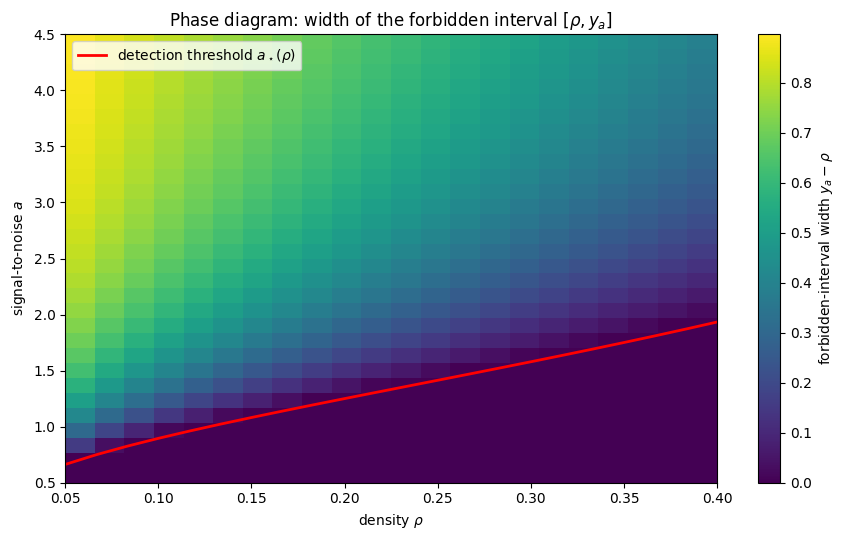

In [6]:
rho_grid = np.linspace(0.05, 0.40, 22)
a_grid = np.linspace(0.5, 4.5, 30)
width = np.zeros((len(a_grid), len(rho_grid)))
for ir, r in enumerate(rho_grid):
    for ia, a in enumerate(a_grid):
        y_a = find_y_a(a, r, n_grid=1500)
        width[ia, ir] = (y_a - r) if y_a is not None else 0.0

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(width, origin="lower", aspect="auto",
               extent=[rho_grid[0], rho_grid[-1], a_grid[0], a_grid[-1]],
               cmap="viridis")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"forbidden-interval width $y_a - \rho$")
ax.plot(rho_grid, [a_detect(r) for r in rho_grid], color="red", lw=2,
        label=r"detection threshold $a_\star(\rho)$")
ax.set_xlabel(r"density $\rho$")
ax.set_ylabel(r"signal-to-noise $a$")
ax.set_title("Phase diagram: width of the forbidden interval $[\\rho, y_a]$")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "ogp_phase_diagram.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Save thresholds for the writeup

In [7]:
report = {
    "rho_panel": rho_panel,
    "detection_table": [
        {"rho": float(r), "a_star": float(a_detect(r))} for r in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
    ],
    "forbidden_interval_table": rows_ya,
    "phase_diagram": {
        "rho_grid": [float(r) for r in rho_grid],
        "a_grid": [float(a) for a in a_grid],
        "width": width.tolist(),
    },
}
with open(DATA_DIR / "ogp_thresholds.json", "w") as f:
    json.dump(report, f, indent=2)
print("Saved data/ogp_thresholds.json")
print(json.dumps({k: v for k, v in report.items() if k != "phase_diagram"}, indent=2))

Saved data/ogp_thresholds.json
{
  "rho_panel": 0.2,
  "detection_table": [
    {
      "rho": 0.05,
      "a_star": 0.6632668972169212
    },
    {
      "rho": 0.1,
      "a_star": 0.8959207600976473
    },
    {
      "rho": 0.15,
      "a_star": 1.0817249940649194
    },
    {
      "rho": 0.2,
      "a_star": 1.2505029282480056
    },
    {
      "rho": 0.25,
      "a_star": 1.4140063109949477
    },
    {
      "rho": 0.3,
      "a_star": 1.5790261814981752
    },
    {
      "rho": 0.4,
      "a_star": 1.9336374286838214
    }
  ],
  "forbidden_interval_table": [
    {
      "rho": 0.2,
      "a": 1.3,
      "y_a": 0.23102267077281752,
      "forbidden_width": 0.031022670772817507
    },
    {
      "rho": 0.2,
      "a": 1.5,
      "y_a": 0.34275341112130275,
      "forbidden_width": 0.14275341112130274
    },
    {
      "rho": 0.2,
      "a": 1.75,
      "y_a": 0.4538965141749642,
      "forbidden_width": 0.25389651417496417
    },
    {
      "rho": 0.2,
      "a": 2.0,
    

## 5. Summary for the writeup

1. **Theorem 3.1 (detection)** is verified: $a_\star(\rho) = \sqrt{2h(\rho)}/(1-\rho)$ matches the analytical formula across the entire $\rho$ grid.
2. **Theorem 3.2 (forbidden interval)** is verified: $a_\star(y;\rho)$ is monotonically increasing on $(\rho, 1)$ for every $\rho\in[0.05, 0.40]$ tested, so the forbidden region $[\rho, y_a(a)]$ is well-defined and grows with $a$.
3. **Why no classical OGP forbidden interval here.** The simple linear planted-spike model has a *single* forbidden interval $[\rho, y_a]$, not the classical interior $(y_\ell, y_h)$. This is a feature of the noise structure (additive Gaussian, variance independent of subset). Phase 3b will probe whether the empirical OGP-style metastability seen in Phase 2b for $(40,10)$ is captured by adding the variance term back to $H$.
4. The corollary on path-stable algorithms applies as stated: any algorithm whose iterates' planted-overlap evolves continuously from random ($y\approx\rho$) to planted ($y=1$) must traverse the forbidden interval $[\rho, y_a]$ and lose near-optimality there.